# Guía de Trabajo Práctico 06
**Materia**: Aprendizaje Profundo Basado en la Física (optativa del Instituto Balseiro)  
**Docente**: José I. Robledo  
**Edición**: abril-mayo 2026

## Inferencia Bayesiana basada en simulaciones

En esta guía vas a trabajar con problemas de **simulation-based inference** (SBI), donde el modelo físico o ingenieril está disponible como simulador pero la verosimilitud puede ser difícil, costosa o directamente inaccesible.

La secuencia queda organizada así:

1. un problema simple para comparar **inferencia bayesiana tradicional** con **ABC**;
2. un simulador de conteos radiactivos para implementar **ABC por rechazo**;
3. el mismo detector resuelto con **SNPE**, **estadísticas resumen**, **embeddings** y un **posterior predictive check**;
4. un oscilador de Duffing como ejemplo de simulador físico no lineal y construcción de estadísticas resumen;
5. una comparación entre **SNPE**, **SNLE** y **SNRE** sobre el problema resumido de Duffing.

Usaremos la expresión **estadísticas resumen** como traducción de *summary statistics*. En algunos bloques aparece también el término en inglés porque es habitual en la documentación de `sbi`.

La idea es ir desde un caso controlado, donde conocemos la posterior exacta, hacia problemas donde necesitamos compresión de datos, aproximaciones neuronales y diagnósticos predictivos.

Si el entrenamiento de `sbi` tarda demasiado, reducí primero `num_simulations` y `max_num_epochs`, y recién después aumentalos para mejorar la calidad del posterior.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy import stats
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

from sbi.inference import SNPE, infer
from sbi.analysis import pairplot
from sbi.neural_nets import posterior_nn
from sbi.utils import BoxUniform

seed = 42
rng = np.random.default_rng(seed)
torch.manual_seed(seed)
np.random.seed(seed)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


---
## Ejercicio 1 — Moneda sesgada: Bayes exacto vs ABC

En este primer problema vamos a inferir la probabilidad $p$ de obtener cara al lanzar una moneda. Es un ejemplo ideal para comparar dos enfoques:

- **inferencia bayesiana tradicional**, donde podemos escribir la posterior exacta porque el modelo Bernoulli con prior Beta es conjugado;
- **ABC por rechazo**, donde evitamos usar la verosimilitud explícita y aceptamos parámetros cuyas simulaciones se parecen a los datos observados.

Trabajá con `n_trials = 50` lanzamientos y una prior uniforme, equivalente a $\mathrm{Beta}(1,1)$.

1. Generar una secuencia de observaciones con un valor verdadero `p_true` elegido por ustedes.
2. Calcular la posterior exacta $\mathrm{Beta}(\alpha,\beta)$ luego de observar los datos.
3. Graficar la posterior exacta para distintos tamaños de muestra: `0, 1, 2, 5, 10, 20, 50` lanzamientos.
4. Implementar un ABC por rechazo usando como simulador una moneda con parámetro `p` y como distancia la discrepancia entre el número de caras simulado y observado.
5. Repetir ABC con al menos dos tolerancias distintas o aceptando distintos porcentajes de muestras.
6. Comparar el histograma de muestras aceptadas por ABC con la posterior exacta.
7. Discutir por qué, en este problema, el número total de caras funciona como estadística suficiente.

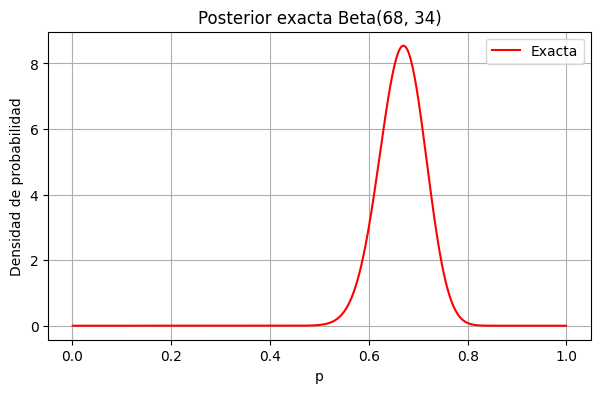

In [18]:
p_true = 0.63
n_trials = 100
coin_data = stats.bernoulli.rvs(p_true, size=n_trials, random_state=seed)
ps = np.linspace(0.001, 0.999, 500)
heads_obs = int(coin_data.sum())

# 1. Calcular alpha_post y beta_post para distintos prefijos de coin_data.
alpha_post = 1 + heads_obs
beta_post = 1 + n_trials - heads_obs
# 2. Graficar las distribuciones Beta exactas.
exact_pdf = stats.beta.pdf(ps, alpha_post, beta_post)
plt.plot(ps, exact_pdf, label="Exacta", color="red")
plt.xlabel("p")
plt.ylabel("Densidad de probabilidad")
plt.title(f"Posterior exacta Beta({alpha_post}, {beta_post})")
plt.legend()
plt.show()


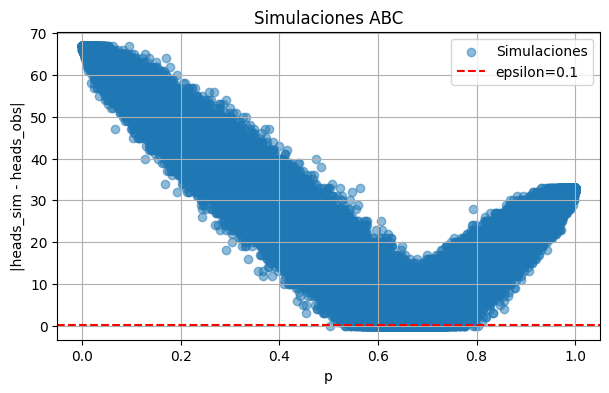

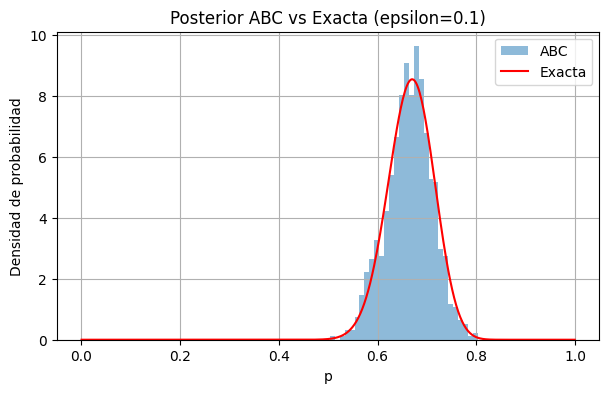

In [19]:
p_sim = rng.uniform(0, 1, size=100000)
heads_sim = stats.bernoulli.rvs(p_sim[:, None], size=(100000, n_trials), random_state=seed).sum(axis=1)
epsilon = 1e-1
accepted = np.abs(heads_sim - heads_obs) <= epsilon
p_accepted = p_sim[accepted]

# Plot p vs differencia entre heads_sim y heads_obs
plt.scatter(p_sim, np.abs(heads_sim - heads_obs), alpha=0.5, label="Simulaciones")
plt.axhline(epsilon, color="red", linestyle="--", label=f"epsilon={epsilon}")
plt.xlabel("p")
plt.ylabel("|heads_sim - heads_obs|")
plt.title("Simulaciones ABC")
plt.legend()
plt.show()


plt.hist(p_accepted, bins=30, density=True, alpha=0.5, label="ABC")
plt.plot(ps, exact_pdf, label="Exacta", color="red")
plt.xlabel("p")
plt.ylabel("Densidad de probabilidad")
plt.title(f"Posterior ABC vs Exacta (epsilon={epsilon})")
plt.legend()
plt.show()

In [ ]:

# 3. Implementar un simulador ABC para el numero de caras.
p_sim = rng.uniform(0, 1, size=10000)
heads_sim = stats.bernoulli.rvs(p_sim, size=(10000, n_trials), random_state=seed).sum(axis=1)

# 4. Muestrear muchos valores de p desde la prior y aceptar los que reproduzcan mejor heads_obs.
# 5. Comparar las muestras aceptadas contra la posterior exacta.

# Sugerencia:
# alpha_post = 1 + heads_obs
# beta_post = 1 + n_trials - heads_obs
# exact_pdf = stats.beta.pdf(ps, alpha_post, beta_post)


---
## Ejercicio 2 — ABC por rechazo en conteos radiactivos

Ahora consideremos un detector que registra conteos de una fuente radiactiva en distintas ventanas temporales. El número esperado de conteos en el tiempo $t_i$ se modela como

$$
\mu_i(\lambda, \epsilon, b) = N_0\,\epsilon\,\exp(-\lambda t_i) + b,
$$

donde $\lambda$ es la tasa de decaimiento, $\epsilon$ es la eficiencia del detector y $b$ es un fondo aproximadamente constante. La observación se genera como

$$
x_i \sim \mathrm{Poisson}(\mu_i).
$$

1. Definir una prior uniforme sobre $\theta=(\lambda,\epsilon,b)$ usando rangos físicamente razonables.
2. Implementar un simulador vectorizado que acepte un tensor `theta` de forma `(n, 3)` y devuelva conteos de forma `(n, n_times)`.
3. Generar una observación sintética `x_obs` a partir de un `theta_true=(0.42, 0.78, 6.0)`.
4. Implementar ABC por rechazo:
   - muestrear muchos parámetros del prior;
   - simular datos para cada parámetro;
   - calcular una distancia entre simulación y observación;
   - aceptar el 1%, 2% o 5% más cercano.
5. Repetir el punto anterior usando estadísticas resumen en lugar de las observaciones completas. Por ejemplo: conteo total, razón temprano/tardío y pendiente de una regresión lineal de `log(counts + 1)` contra el tiempo.
6. Graficar las muestras aceptadas en pares de parámetros e indicar dónde está `theta_true`.


In [9]:
import torch
from sbi.utils import BoxUniform

times_counts = torch.linspace(0.5, 12.0, 100)
N0 = 350.0
theta_true_counts = torch.tensor([[0.42, 0.78, 6.0]])

prior_counts = BoxUniform(
    low=torch.tensor([0.05, 0.35, 0.0]),
    high=torch.tensor([1.20, 0.98, 18.0]),
)


def radioactive_simulator(theta):
    """Simulador vectorizado de conteos Poisson.

    Parametros
    ----------
    theta : torch.Tensor, shape (n, 3)
        Columnas: lambda, eficiencia, fondo.
    """
    # Completar: construir mean_counts con broadcasting y devolver torch.poisson(mean_counts).
    mean_counts = N0 * theta[:,1:2] * torch.exp(-theta[:,0:1] * times_counts) + theta[:,2:3]
    # Recordar que la salida debe tener shape (n, len(times_counts)).
    return torch.poisson(mean_counts)

def compute_summary_statistics(counts):
    """Estadisticas resumen para una matriz de conteos."""
    total = counts.sum(dim=1, keepdim=True).to(dtype=torch.float32)
    early_mean = counts[:, :6].mean(dim=1, keepdim=True).to(dtype=torch.float32)
    late_mean = counts[:, 6:].mean(dim=1, keepdim=True).to(dtype=torch.float32)
    ratio = early_mean / late_mean.clamp_min(1e-6)
    late_times = times_counts[6:].to(dtype=torch.float32, device=counts.device).unsqueeze(0)
    late_log_counts = torch.log1p(counts[:, 6:].to(dtype=torch.float32))
    centered_t = late_times - late_times.mean(dim=1, keepdim=True)
    centered_y = late_log_counts - late_log_counts.mean(dim=1, keepdim=True)
    slope = (centered_t * centered_y).sum(dim=1, keepdim=True) / (centered_t.pow(2).sum(dim=1, keepdim=True) + 1e-6)
    ratio = torch.nan_to_num(ratio, nan=0.0, posinf=0.0, neginf=0.0)
    slope = torch.nan_to_num(slope, nan=0.0, posinf=0.0, neginf=0.0)
    # Sugerencia: total, media temprana, media tardia, razon temprana/tardia, pendiente log-lineal.
    return torch.cat([total, early_mean, late_mean, ratio, slope], dim=1)



In [10]:
# Generar datos observados con el simulador y theta_true_counts.
observed_counts = radioactive_simulator(theta_true_counts).squeeze()
x_obs = observed_counts
print("Datos observados:", observed_counts)


Datos observados: tensor([218., 196., 202., 221., 164., 177., 167., 158., 149., 127., 138., 139.,
        113., 133., 129., 108., 121., 126., 105.,  94.,  87.,  76.,  84.,  68.,
         71.,  69.,  78.,  71.,  90.,  60.,  46.,  67.,  54.,  44.,  50.,  49.,
         38.,  38.,  44.,  37.,  32.,  34.,  26.,  42.,  28.,  26.,  27.,  32.,
         33.,  30.,  25.,  32.,  30.,  20.,  20.,  22.,  16.,  17.,  26.,  17.,
         18.,  28.,  18.,  23.,  14.,  13.,  10.,   4.,  11.,  15.,  13.,  13.,
          5.,  10.,  15.,   6.,  10.,  10.,  10.,   7.,   5.,   7.,  16.,  11.,
         14.,   7.,  10.,  11.,  11.,  11.,  12.,  12.,  12.,   4.,   9.,  13.,
          5.,   5.,   7.,   5.])


In [11]:
# Simular datos sampleando theta desde la prior
n_simulations = 1000000
theta_sim = prior_counts.sample((n_simulations,))
simulated_counts = radioactive_simulator(theta_sim)
print("Simulated counts shape:", simulated_counts.shape)


Simulated counts shape: torch.Size([1000000, 100])


In [12]:
# Calcular una distancia robusta entre cada simulacion y los datos observados.
# El termino principal compara los conteos normalizados punto a punto, y dos estadisticas resumen
# ayudan a romper degeneraciones entre lambda, eficiencia y fondo.

std_dev = torch.std(simulated_counts, dim=0, unbiased=False).clamp_min(1e-6)
normalized_diff = (simulated_counts - observed_counts) / std_dev

summary_observed_local = compute_summary_statistics(observed_counts.unsqueeze(0))
summary_simulated_local = compute_summary_statistics(simulated_counts)
summary_scale_local = torch.std(summary_simulated_local, dim=0, keepdim=True, unbiased=False).clamp_min(1e-6)
normalized_summary_diff_local = (summary_simulated_local - summary_observed_local) / summary_scale_local

combined_diff = torch.cat([normalized_diff, 0.5 * normalized_summary_diff_local], dim=1)
distancias = torch.norm(combined_diff, dim=1)
print("Distancias shape:", distancias.shape)

accepted_quantiles = [0.01, 0.02, 0.05]
accepted_by_quantile = {}
theta_accepted_by_quantile = {}
for quantile in accepted_quantiles:
    epsilon_q = torch.quantile(distancias, quantile)
    accepted_q = distancias <= epsilon_q
    accepted_by_quantile[quantile] = accepted_q
    theta_accepted_by_quantile[quantile] = theta_sim[accepted_q]
    print(f"ABC completo, aceptando el {int(quantile * 100)}% mas cercano: {theta_accepted_by_quantile[quantile].shape[0]} muestras")

# Conservamos las variables usadas por las celdas de visualizacion.
epsilon = torch.quantile(distancias, 0.01)
accepted = accepted_by_quantile[0.01]
theta_accepted = theta_accepted_by_quantile[0.01]


Distancias shape: torch.Size([1000000])
ABC completo, aceptando el 1% mas cercano: 10000 muestras
ABC completo, aceptando el 2% mas cercano: 20000 muestras
ABC completo, aceptando el 5% mas cercano: 50000 muestras


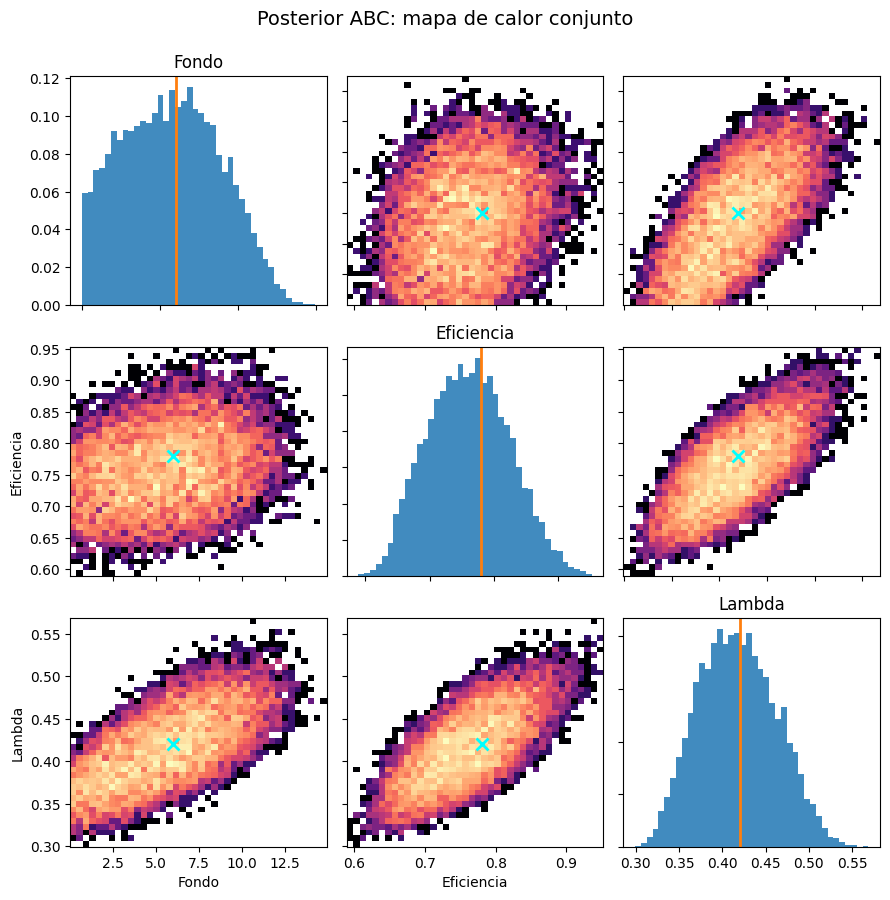

In [13]:
from matplotlib.colors import LogNorm

# Mapa de calor conjunto para ver densidad posterior sin sobrecarga visual.
display_indices = [2, 1, 0]
theta_display = theta_accepted.cpu()[:, display_indices]
true_theta = theta_true_counts.squeeze(0).cpu()[display_indices]
parameter_labels = ["Fondo", "Eficiencia", "Lambda"]

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row in range(3):
    for column in range(3):
        ax = axes[row, column]
        if row == column:
            ax.hist(theta_display[:, column].numpy(), bins=40, density=True, color="tab:blue", alpha=0.85)
            ax.axvline(true_theta[column].item(), color="tab:orange", lw=2)
            ax.set_title(parameter_labels[column])
        else:
            heat = ax.hist2d(
                theta_display[:, column].numpy(),
                theta_display[:, row].numpy(),
                bins=40,
                cmap="magma",
                norm=LogNorm(vmin=1),
            )
            ax.plot(
                true_theta[column].item(),
                true_theta[row].item(),
                marker="x",
                markersize=9,
                markeredgewidth=2,
                color="cyan",
                linestyle="None",
            )
            if column == 0:
                ax.set_ylabel(parameter_labels[row])
            if row == 2:
                ax.set_xlabel(parameter_labels[column])
        if row != 2:
            ax.set_xticklabels([])
        if column != 0:
            ax.set_yticklabels([])
        ax.grid(False)

fig.suptitle("Posterior ABC: mapa de calor conjunto", y=0.995, fontsize=14)
fig.tight_layout()
plt.show()

In [14]:
# Computar estadisticas resumen para los datos observados y simulados, y repetir el proceso de ABC usando estas estadisticas.
summary_observed = torch.nan_to_num(compute_summary_statistics(observed_counts.unsqueeze(0)), nan=0.0, posinf=0.0, neginf=0.0)
summary_simulated = torch.nan_to_num(compute_summary_statistics(simulated_counts), nan=0.0, posinf=0.0, neginf=0.0)

# Normalizar por la desviacion estandar de cada estadistica resumen a lo largo de las simulaciones puede ayudar a mejorar el rendimiento de ABC.
summary_scale = torch.std(summary_simulated, dim=0, keepdim=True).clamp_min(1e-6)
normalized_summary_diff = (summary_simulated - summary_observed) / summary_scale
distancias_summary = torch.norm(normalized_summary_diff, dim=1)

accepted_summary_quantiles = [0.01, 0.02, 0.05]
accepted_summary_by_quantile = {}
theta_accepted_summary_by_quantile = {}
for quantile in accepted_summary_quantiles:
    epsilon_summary_q = torch.quantile(distancias_summary, quantile)
    accepted_summary_q = distancias_summary <= epsilon_summary_q
    accepted_summary_by_quantile[quantile] = accepted_summary_q
    theta_accepted_summary_by_quantile[quantile] = theta_sim[accepted_summary_q]
    print(f"ABC con resumenes, aceptando el {int(quantile * 100)}% mas cercano: {theta_accepted_summary_by_quantile[quantile].shape[0]} muestras")

epsilon_summary = torch.quantile(distancias_summary, 0.05)
accepted_summary = accepted_summary_by_quantile[0.05]
theta_accepted_summary = theta_accepted_summary_by_quantile[0.05]


ABC con resumenes, aceptando el 1% mas cercano: 10000 muestras
ABC con resumenes, aceptando el 2% mas cercano: 20000 muestras
ABC con resumenes, aceptando el 5% mas cercano: 50000 muestras


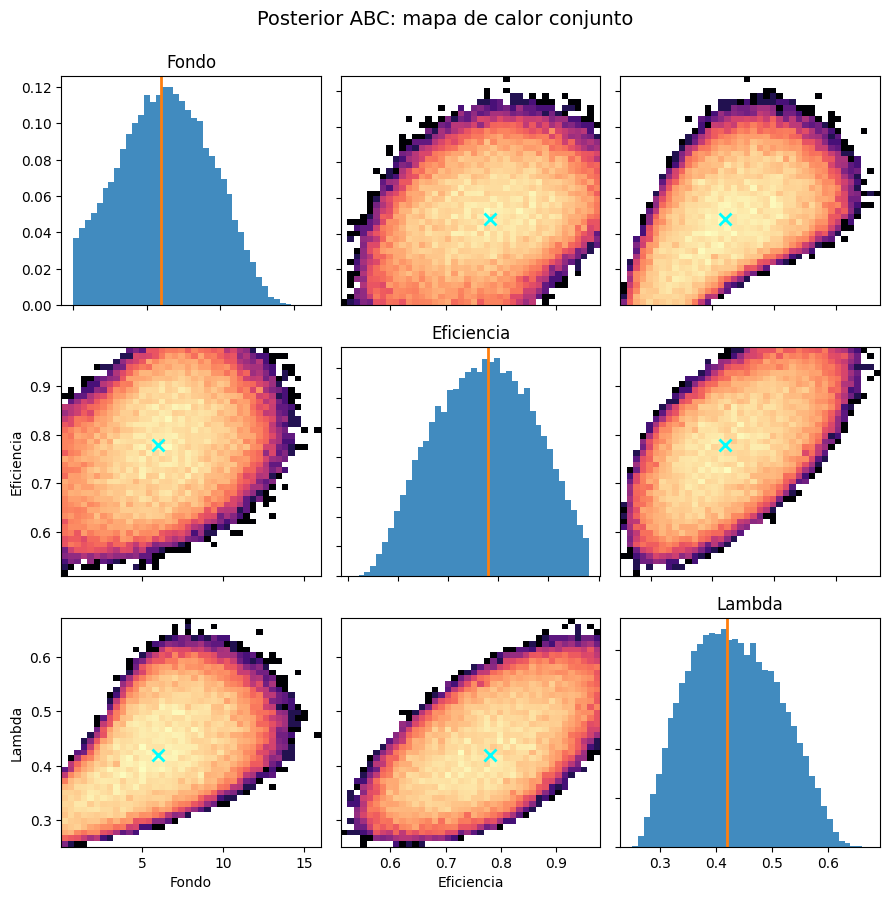

In [15]:
from matplotlib.colors import LogNorm

# Mapa de calor conjunto para la posterior basada en estadisticas resumen.
display_indices = [2, 1, 0]
theta_display_summary = theta_accepted_summary.cpu()[:, display_indices]
true_theta = theta_true_counts.squeeze(0).cpu()[display_indices]
parameter_labels = ["Fondo", "Eficiencia", "Lambda"]

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row in range(3):
    for column in range(3):
        ax = axes[row, column]
        if row == column:
            ax.hist(theta_display_summary[:, column].numpy(), bins=40, density=True, color="tab:blue", alpha=0.85)
            ax.axvline(true_theta[column].item(), color="tab:orange", lw=2)
            ax.set_title(parameter_labels[column])
        else:
            ax.hist2d(
                theta_display_summary[:, column].numpy(),
                theta_display_summary[:, row].numpy(),
                bins=40,
                cmap="magma",
                norm=LogNorm(vmin=1),
            )
            ax.plot(
                true_theta[column].item(),
                true_theta[row].item(),
                marker="x",
                markersize=9,
                markeredgewidth=2,
                color="cyan",
                linestyle="None",
            )
            if column == 0:
                ax.set_ylabel(parameter_labels[row])
            if row == 2:
                ax.set_xlabel(parameter_labels[column])
        if row != 2:
            ax.set_xticklabels([])
        if column != 0:
            ax.set_yticklabels([])
        ax.grid(False)

fig.suptitle("Posterior ABC: mapa de calor conjunto", y=0.995, fontsize=14)
fig.tight_layout()
plt.show()

---
## Ejercicio 3 — SNPE para el detector: estadísticas resumen, embeddings y PPC

Ahora reutilizá el simulador del detector radiactivo para entrenar una posterior neuronal con `SNPE`. 

1. Generar un conjunto de entrenamiento con pares `(theta, x)` simulados desde `prior_counts`.
2. Entrenar `SNPE` usando las estadísticas resumen de `count_summaries(x)`.
3. Definir una `embedding_net` pequeña y entrenar otro `SNPE` directamente sobre los conteos completos.
4. Comparar visualmente los posteriores obtenidos con estadísticas resumen manuales y con embedding aprendido.
5. Calcular media posterior, desvío estándar e intervalo creíble central del 90% para cada parámetro.
6. Realizar un **posterior predictive check (PPC)** con al menos 100 muestras posteriores:
   - muestrear parámetros desde la posterior;
   - volver a simular conteos;
   - graficar la observación, la mediana predictiva y una banda central del 90%.
7. Discutir qué gana y qué pierde cada enfoque: interpretabilidad de las estadísticas resumen manuales frente a flexibilidad del embedding aprendido.

 Neural network successfully converged after 97 epochs.

/home/miguel/miniconda3/envs/tesis/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 78 epochs.

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

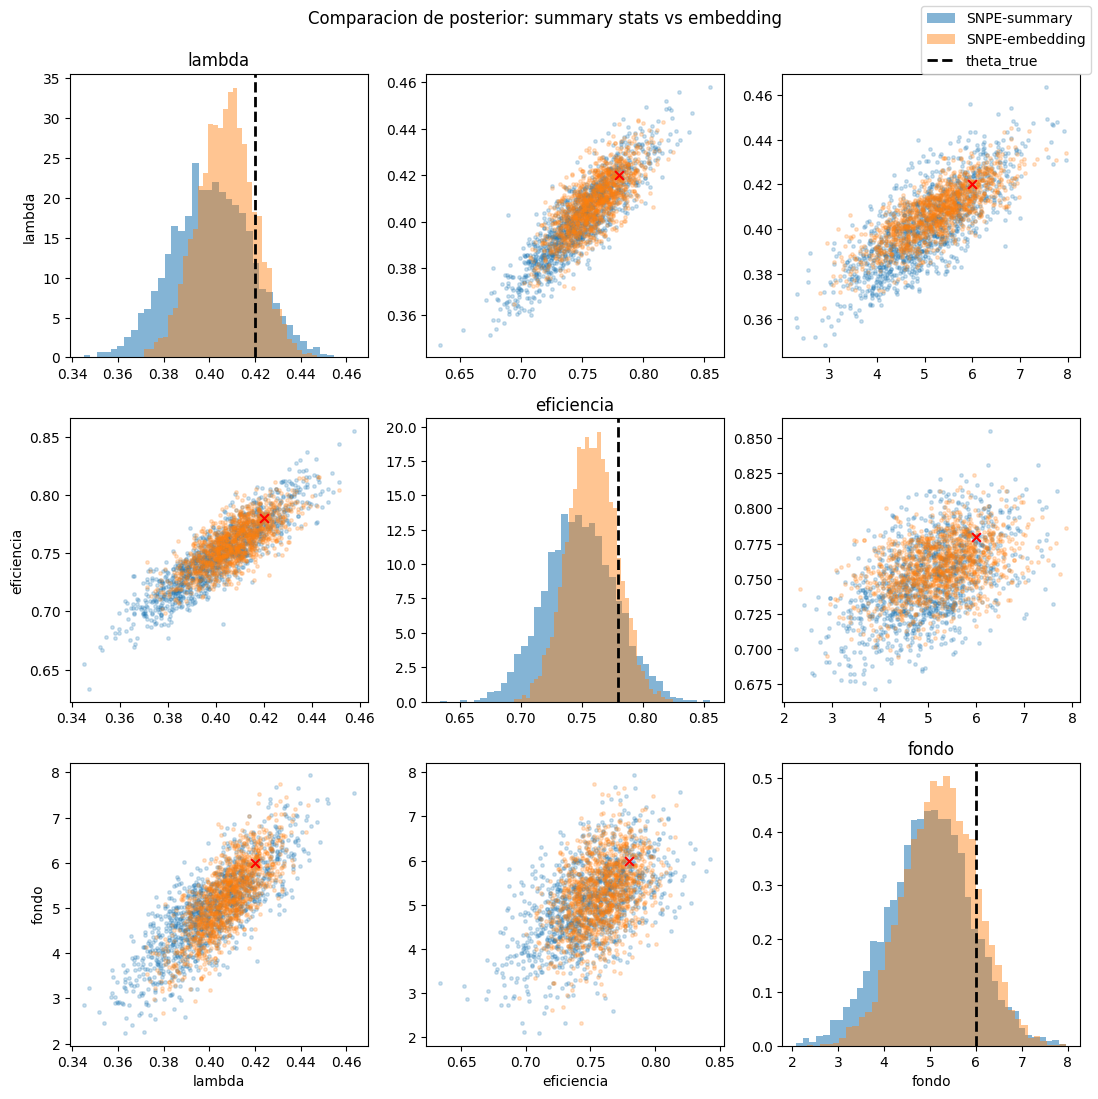


SNPE con estadisticas resumen
parametro        media      std      q05      q95
lambda        0.4013   0.0177   0.3724   0.4313
eficiencia    0.7486   0.0291   0.7006   0.7983
fondo         4.9875   0.9172   3.4365   6.4781

SNPE con embedding
parametro        media      std      q05      q95
lambda        0.4074   0.0123   0.3873   0.4274
eficiencia    0.7585   0.0201   0.7252   0.7916
fondo         5.2322   0.7924   3.9445   6.5337


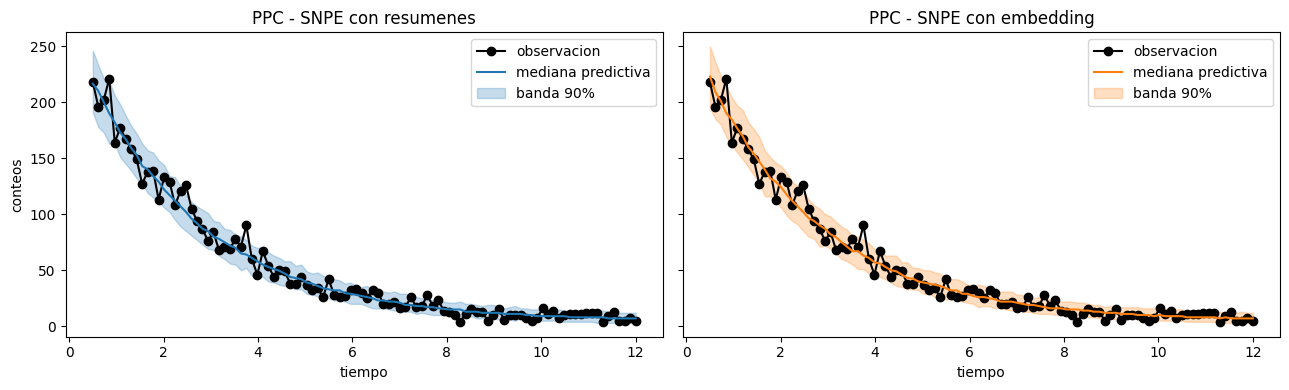


Discusion:
- Summary stats manuales: mas interpretables y faciles de diagnosticar, pero pueden perder informacion de los conteos completos.
- Embedding aprendido: puede capturar patrones no lineales y detalles finos sin disenar estadisticas a mano,
  pero resulta menos interpretable y puede requerir mas simulaciones/ajuste para estabilidad.


In [18]:
# Ejercicio 3: SNPE con resumenes manuales vs embedding aprendido
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sbi.inference import SNPE
from sbi.neural_nets import posterior_nn
from sbi.utils import BoxUniform
device = "cuda" if torch.cuda.is_available() else "cpu"
# Usamos la funcion de resumen ya definida en el notebook.
summary_fn = globals().get("count_summaries", None)
if summary_fn is None:
    summary_fn = compute_summary_statistics

# Observacion sintetica para condicionar las posteriors.
if "observed_counts" in globals():
    x_obs_counts = observed_counts.unsqueeze(0) if observed_counts.ndim == 1 else observed_counts
else:
    x_obs_counts = radioactive_simulator(theta_true_counts)

# 1) Generar dataset de entrenamiento (theta, x) desde prior_counts.
num_simulations_snpe = 100000
theta_train = prior_counts.sample((num_simulations_snpe,))
x_train = radioactive_simulator(theta_train)

# 2) SNPE usando estadisticas resumen manuales.
x_summary_train = torch.nan_to_num(summary_fn(x_train), nan=0.0, posinf=0.0, neginf=0.0)
x_obs_summary = torch.nan_to_num(summary_fn(x_obs_counts), nan=0.0, posinf=0.0, neginf=0.0)

# Estandarizacion ligera para estabilizar entrenamiento en summaries.
summary_scale = x_summary_train.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6)
x_summary_train_norm = x_summary_train / summary_scale
x_obs_summary_norm = x_obs_summary / summary_scale

density_estimator_summary = posterior_nn(model="maf")
inference_summary = SNPE(prior=prior_counts, density_estimator=density_estimator_summary, device=device)
_ = inference_summary.append_simulations(theta_train.to(device), x_summary_train_norm.to(device)).train(
    training_batch_size=256
)
posterior_summary = inference_summary.build_posterior(prior=prior_counts).set_default_x(
    x_obs_summary_norm.squeeze(0).to(device)
)


# 3) SNPE sobre conteos completos con embedding pequeno.
class CountEmbeddingNet(nn.Module):
    def __init__(self, n_bins, embedding_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_bins, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim),
        )

    def forward(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        return self.net(x)


embedding_net = CountEmbeddingNet(n_bins=x_train.shape[1], embedding_dim=8)
density_estimator_embed = posterior_nn(model="maf", embedding_net=embedding_net)
inference_embed = SNPE(prior=prior_counts, density_estimator=density_estimator_embed, device=device)
_ = inference_embed.append_simulations(theta_train.to(device), x_train.to(device)).train(training_batch_size=256)
posterior_embed = inference_embed.build_posterior(prior=prior_counts).set_default_x(
    x_obs_counts.squeeze(0).to(device)
)


# 4) Comparacion visual de posteriors.
num_posterior_draws = 4000
theta_post_summary = posterior_summary.sample((num_posterior_draws,)).detach().cpu()
theta_post_embed = posterior_embed.sample((num_posterior_draws,)).detach().cpu()
theta_true = theta_true_counts.squeeze(0).cpu()

param_names = ["lambda", "eficiencia", "fondo"]
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        if i == j:
            ax.hist(theta_post_summary[:, j].numpy(), bins=40, density=True, alpha=0.55, label="SNPE-summary")
            ax.hist(theta_post_embed[:, j].numpy(), bins=40, density=True, alpha=0.45, label="SNPE-embedding")
            ax.axvline(theta_true[j].item(), color="k", linestyle="--", linewidth=2, label="theta_true")
            ax.set_title(param_names[j])
        else:
            idx = torch.randperm(num_posterior_draws)[:1200]
            ax.scatter(
                theta_post_summary[idx, j].numpy(),
                theta_post_summary[idx, i].numpy(),
                s=6,
                alpha=0.22,
                label="summary",
            )
            ax.scatter(
                theta_post_embed[idx, j].numpy(),
                theta_post_embed[idx, i].numpy(),
                s=6,
                alpha=0.22,
                label="embedding",
            )
            ax.scatter(theta_true[j].item(), theta_true[i].item(), c="red", s=40, marker="x")
        if i == 2:
            ax.set_xlabel(param_names[j])
        if j == 0:
            ax.set_ylabel(param_names[i])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Comparacion de posterior: summary stats vs embedding", y=0.995)
fig.tight_layout()
plt.show()


# 5) Estadisticas posteriores: media, desvio e IC central 90%.
def posterior_report(samples, method_name):
    mean = samples.mean(dim=0)
    std = samples.std(dim=0, unbiased=False)
    q05 = torch.quantile(samples, 0.05, dim=0)
    q95 = torch.quantile(samples, 0.95, dim=0)

    print(f"\n{method_name}")
    print("parametro        media      std      q05      q95")
    for k, pname in enumerate(param_names):
        print(f"{pname:10s}  {mean[k].item():8.4f}  {std[k].item():7.4f}  {q05[k].item():7.4f}  {q95[k].item():7.4f}")


posterior_report(theta_post_summary, "SNPE con estadisticas resumen")
posterior_report(theta_post_embed, "SNPE con embedding")


# 6) Posterior predictive check (PPC) con al menos 100 muestras.
def posterior_predictive_band(theta_samples, n_ppc=200):
    idx = torch.randperm(theta_samples.shape[0])[:n_ppc]
    theta_ppc = theta_samples[idx]
    x_ppc = radioactive_simulator(theta_ppc)
    median = torch.quantile(x_ppc, 0.50, dim=0)
    lo = torch.quantile(x_ppc, 0.05, dim=0)
    hi = torch.quantile(x_ppc, 0.95, dim=0)
    return median, lo, hi


med_s, lo_s, hi_s = posterior_predictive_band(theta_post_summary, n_ppc=200)
med_e, lo_e, hi_e = posterior_predictive_band(theta_post_embed, n_ppc=200)

x_axis = times_counts.cpu().numpy()
y_obs = x_obs_counts.squeeze(0).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(x_axis, y_obs, "o-", color="black", label="observacion")
axes[0].plot(x_axis, med_s.cpu().numpy(), color="tab:blue", label="mediana predictiva")
axes[0].fill_between(x_axis, lo_s.cpu().numpy(), hi_s.cpu().numpy(), color="tab:blue", alpha=0.25, label="banda 90%")
axes[0].set_title("PPC - SNPE con resumenes")
axes[0].set_xlabel("tiempo")
axes[0].set_ylabel("conteos")
axes[0].legend()

axes[1].plot(x_axis, y_obs, "o-", color="black", label="observacion")
axes[1].plot(x_axis, med_e.cpu().numpy(), color="tab:orange", label="mediana predictiva")
axes[1].fill_between(x_axis, lo_e.cpu().numpy(), hi_e.cpu().numpy(), color="tab:orange", alpha=0.25, label="banda 90%")
axes[1].set_title("PPC - SNPE con embedding")
axes[1].set_xlabel("tiempo")
axes[1].legend()

plt.tight_layout()
plt.show()


# 7) Discusion breve: interpretabilidad vs flexibilidad.
print(
    "\nDiscusion:\n"
    "- Summary stats manuales: mas interpretables y faciles de diagnosticar, pero pueden perder informacion de los conteos completos.\n"
    "- Embedding aprendido: puede capturar patrones no lineales y detalles finos sin disenar estadisticas a mano,\n"
    "  pero resulta menos interpretable y puede requerir mas simulaciones/ajuste para estabilidad."
)

---
## Ejercicio 4 — Oscilador de Duffing

En muchos problemas de física e ingeniería, una simulación devuelve una trayectoria temporal larga y no un vector corto. Para practicar ese caso vamos a usar un **oscilador de Duffing amortiguado y forzado**.

El modelo para el desplazamiento $x(t)$ es

$$
\ddot{x} + 2\gamma \dot{x} + \omega_0^2 x + \beta x^3 = F\cos(\omega_d t),
$$

donde vamos a inferir
$$
\theta = (\gamma, \beta, F, \sigma),
$$
con $\sigma$ representando ruido gaussiano de medición.

El objetivo de este ejercicio no es todavía entrenar un método de `sbi`, sino pensar **cómo resumir una trayectoria** de manera razonable.

1. Ejecutar el simulador provisto para varios valores de `theta` y visualizar las trayectorias $x(t)$.
2. Generar una observación sintética con un `theta_true_duffing` conocido.
3. Construir una función `summarize_duffing(x)` con un conjunto corto de estadísticas resumen informativas. Por ejemplo:
   - media y desvío estándar;
   - amplitud máxima;
   - RMS de la parte estacionaria;
   - frecuencia dominante estimada con la FFT;
   - cantidad de máximos detectados con `find_peaks`.
4. Comparar la dimensión de la trayectoria completa con la dimensión del resumen.
5. Explicar brevemente qué parámetros deberían quedar mejor informados por cada estadística y dónde esperan degeneraciones.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
import torch
t_duffing = np.linspace(0.0, 50.0, 500)
x0_duffing = np.array([0.15, 0.0])
omega0_duffing = 1.0
omega_drive_duffing = 0.85


def solve_duffing(theta, t_eval=t_duffing, x0=x0_duffing):
    """Simular posicion observada de un oscilador de Duffing.

    Parametros
    ----------
    theta : array-like, shape (4,)
        gamma, beta, F, sigma.
    """
    gamma, beta, force, sigma = [float(v) for v in theta]

    def rhs(t, y):
        x, v = y
        drive = force * np.cos(omega_drive_duffing * t)
        dxdt = v
        dvdt = drive - 2.0 * gamma * v - omega0_duffing**2 * x - beta * x**3
        return [dxdt, dvdt]

    sol = solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        x0,
        t_eval=t_eval,
        rtol=1e-6,
        atol=1e-8,
        max_step=0.1,
    )
    clean_position = sol.y[0].astype(np.float32)
    noisy_position = clean_position + rng.normal(0.0, sigma, size=clean_position.shape).astype(np.float32)
    return noisy_position


def plot_duffing_trace(position, title="Oscilador de Duffing"):
    plt.plot(t_duffing, position, label="posicion observada")
    plt.plot(
        t_duffing,
        0.15 * np.cos(omega_drive_duffing * t_duffing),
        "--",
        alpha=0.7,
        label="referencia de fase",
    )
    plt.xlabel("tiempo")
    plt.ylabel("x(t)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_duffing(position):
    """Convertir una trayectoria x(t) en un vector corto de estadisticas resumen."""
    position = np.asarray(position, dtype=np.float32)
    mean_position = float(position.mean())
    std_position = float(position.std())
    amplitude_position = float(position.max() - position.min())
    half_index = position.shape[0] // 2
    stationary_segment = position[half_index:]
    rms_stationary = float(np.sqrt(np.mean(stationary_segment**2)))
    dt = float(t_duffing[1] - t_duffing[0])
    centered_position = position - mean_position
    frequency_grid = np.fft.rfftfreq(position.shape[0], d=dt)
    spectrum = np.abs(np.fft.rfft(centered_position))
    dominant_frequency = float(frequency_grid[1 + np.argmax(spectrum[1:])]) if spectrum.shape[0] > 1 else 0.0
    peak_indices, _ = find_peaks(position)
    n_peaks = float(peak_indices.size)
    return torch.tensor(
        [mean_position, std_position, amplitude_position, rms_stationary, dominant_frequency, n_peaks],
        dtype=torch.float32,
    )


def duffing_summary_simulator(theta):
    """Wrapper compatible con sbi: theta tiene shape (n, 4)."""
    summaries = []
    for row in theta.detach().cpu().numpy():
        position = solve_duffing(row)
        summaries.append(summarize_duffing(position))
    return torch.as_tensor(np.stack(summaries), dtype=torch.float32)


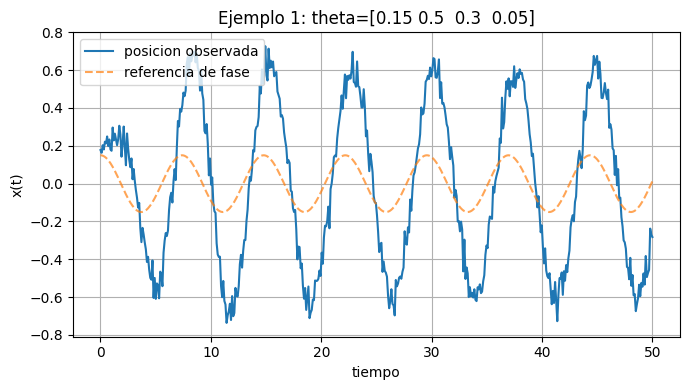

In [23]:
# Ejecutar el simulador y visualizar varias trayectorias para distintos theta.
theta_examples = np.array(
    [
        [0.15, 0.5, 0.3, 0.05],
        # [0.25, 0.5, 0.3, 0.05],
        # [0.15, 1.0, 0.3, 0.05],
        # [0.15, 0.5, 0.6, 0.05],
        # [0.15, 0.5, 0.3, 0.1],
    ]
)
for i, theta in enumerate(theta_examples):
    position = solve_duffing(theta)
    plot_duffing_trace(position, title=f"Ejemplo {i+1}: theta={theta}")


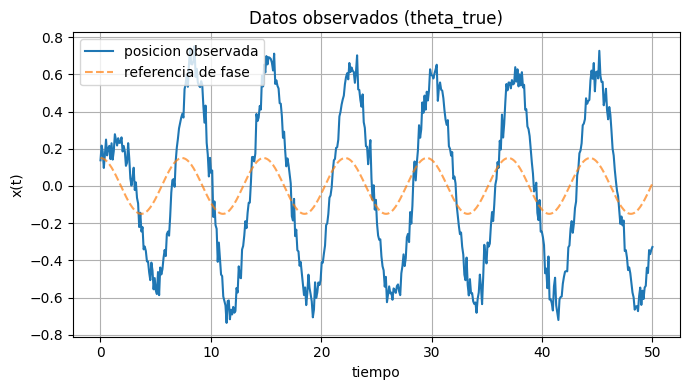

Estadisticas resumen de los datos observados: [-1.2965814e-02  4.3011278e-01  1.4872305e+00  4.4124752e-01
  1.3971999e-01  1.3200000e+02]
Dimension de la trayectoria completa: 500
Dimension de las estadisticas resumen: 6


In [25]:
theta_true_duffing = np.array([0.15, 0.5, 0.3, 0.05])
position_obs_duffing = solve_duffing(theta_true_duffing)
plot_duffing_trace(position_obs_duffing, title="Datos observados (theta_true)")
summary_obs_duffing = summarize_duffing(position_obs_duffing)
print("Estadisticas resumen de los datos observados:", summary_obs_duffing.numpy())
# Comparar la dimension de la trayectoria completa (len(t_duffing)) con la dimension de las estadisticas resumen (summary_obs_duffing.shape[0]).
print(f"Dimension de la trayectoria completa: {len(t_duffing)}")
print(f"Dimension de las estadisticas resumen: {summary_obs_duffing.shape[0]}")

---
## Ejercicio 5 — Comparar SNPE, SNLE y SNRE

Con el simulador de Duffing resumido, vamos a comparar tres familias de métodos disponibles en `sbi`:

- **SNPE**: aproxima directamente $p(\theta \mid x)$;
- **SNLE** o **NLE**: aproxima $p(x \mid \theta)$ y luego construye el posterior;
- **SNRE** o **NRE**: aproxima razones de verosimilitud mediante clasificación.

1. Definir una prior para $\gamma$, $\beta$, $F$ y $\sigma$.
2. Entrenar SNPE con `SNPE(...)` o con `infer(..., method="SNPE")`.
3. Entrenar SNLE con `infer(..., method="SNLE")` usando el mismo número de simulaciones.
4. Entrenar SNRE con `infer(..., method="SNRE")` usando el mismo número de simulaciones.
5. Muestrear los tres posteriores condicionados a `x_obs_duffing_summary`.
6. Comparar los tres resultados con `pairplot` o con gráficos de dispersión por pares.
7. Registrar el tiempo de entrenamiento y el tiempo de muestreo posterior. ¿Qué método fue más barato? ¿Cuál produjo muestras más estables?
8. Repetir con menos simulaciones y describir cuál de los métodos se degrada primero.
9. Interpretar físicamente las correlaciones posteriores: ¿aparecen compensaciones entre amortiguamiento y fuerza externa? ¿La rigidez no lineal queda bien identificada?


In [ ]:
prior_duffing = BoxUniform(
    low=torch.tensor([0.02, 0.00, 0.05, 0.005]),
    high=torch.tensor([0.22, 4.00, 0.65, 0.080]),
)

# Generar dataset de entrenamiento para SNPE/SNLE/SNRE usando las estadisticas resumen.
num_simulations_duffing = 10
theta_train_duffing = prior_duffing.sample((num_simulations_duffing,))
summary_train_duffing = duffing_summary_simulator(theta_train_duffing)
print("Dataset de entrenamiento generado:")
print("theta_train shape:", theta_train_duffing.shape)
print("summary_train shape:", summary_train_duffing.shape)

# Observacion resumen ya calculada en la celda anterior: summary_obs_duffing
x_obs_duffing = summary_obs_duffing.unsqueeze(0).to(device) if summary_obs_duffing.ndim == 1 else summary_obs_duffing.to(device)

# IMPORTANTE: `infer` ejecuta el pipeline completo (simulaciones internas + entrenamiento) cuando se le pasa `num_simulations`.
# Usamos el mismo presupuesto de simulaciones para los tres metodos.
from sbi.inference import infer

print("Entrenando SNPE (resumenes)...")
posterior_snpe = infer(simulator=duffing_summary_simulator, prior=prior_duffing, method="SNPE", num_simulations=num_simulations_duffing, device=device)
posterior_snpe = posterior_snpe.set_default_x(x_obs_duffing.squeeze(0).to(device))
samples_snpe = posterior_snpe.sample((2000,)).detach().cpu()
print("SNPE entrenado. Muestras obtenidas:", samples_snpe.shape)

print("Entrenando SNLE (resumenes)...")
posterior_snle = infer(simulator=duffing_summary_simulator, prior=prior_duffing, method="SNLE", num_simulations=num_simulations_duffing, device=device)
posterior_snle = posterior_snle.set_default_x(x_obs_duffing.squeeze(0).to(device))
samples_snle = posterior_snle.sample((2000,)).detach().cpu()
print("SNLE entrenado. Muestras obtenidas:", samples_snle.shape)

print("Entrenando SNRE (resumenes)...")
posterior_snre = infer(simulator=duffing_summary_simulator, prior=prior_duffing, method="SNRE", num_simulations=num_simulations_duffing, device=device)
posterior_snre = posterior_snre.set_default_x(x_obs_duffing.squeeze(0).to(device))
samples_snre = posterior_snre.sample((2000,)).detach().cpu()
print("SNRE entrenado. Muestras obtenidas:", samples_snre.shape)

# Comparacion rapida: pairplot de las tres aproximaciones (usa sbi.analysis.pairplot).
import pandas as pd
from sbi.analysis import pairplot

df_snpe = pd.DataFrame(samples_snpe.numpy(), columns=['gamma','beta','F','sigma'])
df_snle = pd.DataFrame(samples_snle.numpy(), columns=['gamma','beta','F','sigma'])
df_snre = pd.DataFrame(samples_snre.numpy(), columns=['gamma','beta','F','sigma'])

print("Graficando pairplots (puede tardar).")
fig = pairplot(samples_snpe.numpy(), labels=['gamma','beta','F','sigma'], title="SNPE (resumen)")
fig = pairplot(samples_snle.numpy(), labels=['gamma','beta','F','sigma'], title="SNLE (resumen)")
fig = pairplot(samples_snre.numpy(), labels=['gamma','beta','F','sigma'], title="SNRE (resumen)")

# Reporte numerico sencillo.
def report(samples, name):
    mean = samples.mean(axis=0)
    std = samples.std(axis=0)
    q05 = np.quantile(samples, 0.05, axis=0)
    q95 = np.quantile(samples, 0.95, axis=0)
    print(f"--- {name} ---")
    for k, lab in enumerate(['gamma','beta','F','sigma']):
        print(f"{lab:6s}: mean={mean[k]:.4f}, std={std[k]:.4f}, q05={q05[k]:.4f}, q95={q95[k]:.4f}")

report(samples_snpe.numpy(), 'SNPE')
report(samples_snle.numpy(), 'SNLE')
report(samples_snre.numpy(), 'SNRE')

print("Entrenamiento y muestreo completados.")


SyntaxError: unmatched ')' (3442910974.py, line 68)